# MIBI-TNBC Comprehensive Exploratory Data Analysis

This notebook performs extensive EDA on the merged MIBI-TNBC master table:
`data/processed/mibi_cellData_with_patient_class_and_centroids.csv`.

**Dataset context**
- **Source:** Angelolab processed MIBI-TNBC (triple-negative breast cancer)
- **Unit of observation:** single segmented cell (~197k cells across **40 samples**)
- **Patient phenotypes** (`patient_class`): 0 = mixed, 1 = compartmentalized, 2 = cold
- **Prior pipeline steps:** centroid extraction from labeled masks, merge with expression + labels, exclusion of samples 42–44

**Why 40 samples, not 41?** `patient_class.csv` lists 41 SampleIDs (1–41), but **sample 30 has zero rows in `cellData.csv`**, so it never enters the master table. Samples 42–44 are in `cellData.csv` but are dropped during merge because they have no patient-class label. The EDA therefore covers **40 samples with cell-level data**.

**What this notebook covers**
1. Table structure, dtypes, and completeness
2. Sample- and patient-level summaries
3. Cell phenotype distributions (tumor status, broad groups, immune subtypes)
4. Marker expression profiles and correlations
5. Spatial layout, density, and phenotype maps
6. Cross-class comparisons and QC checks

## 0. Setup

In [6]:
from pathlib import Path
import sys

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import shared label mappings from src/data
PROJECT_ROOT = Path.cwd().parent if not (Path.cwd() / "data").exists() and (Path.cwd().parent / "data").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src" / "data"))
from mibi_constants import GROUP_LABELS, IMMUNE_GROUP_LABELS, PATIENT_CLASS_LABELS

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_cwd = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda_notebook"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MASTER_PATH = PROCESSED_DIR / "mibi_cellData_with_patient_class_and_centroids.csv"

MARKER_COLUMNS = [
    "C", "Na", "Si", "P", "Ca", "Fe", "dsDNA",
    "Vimentin", "SMA", "Background", "B7H3", "FoxP3", "Lag3",
    "CD4", "CD16", "CD56", "OX40", "PD1", "CD31", "PD-L1",
    "EGFR", "Ki67", "CD209", "CD11c", "CD138", "CD163",
    "CD68", "CSF-1R", "CD8", "CD3", "IDO", "Keratin17",
    "CD63", "CD45RO", "CD20", "p53", "Beta catenin",
    "HLA-DR", "CD11b", "CD45", "H3K9ac", "Pan-Keratin",
    "H3K27me3", "phospho-S6", "MPO", "Keratin6",
    "HLA_Class_1", "Ta", "Au",
]

KEY_MARKERS = [
    "CD3", "CD8", "CD4", "CD45", "CD68", "CD163",
    "Pan-Keratin", "Ki67", "PD1", "PD-L1", "FoxP3", "CD20",
]

METADATA_COLS = [
    "SampleID", "cellLabelInImage", "cellSize", "tumorYN", "tumorCluster",
    "Group", "immuneCluster", "immuneGroup", "patient_class",
    "centroid_x", "centroid_y", "mask_area_pixels",
]

print("Project root:", PROJECT_ROOT)
print("Master table:", MASTER_PATH)
print("Figures output:", FIGURES_DIR)

Project root: c:\Users\Kelly\Documents\spatial-ihc-feature-lab
Master table: c:\Users\Kelly\Documents\spatial-ihc-feature-lab\data\processed\mibi_cellData_with_patient_class_and_centroids.csv
Figures output: c:\Users\Kelly\Documents\spatial-ihc-feature-lab\reports\figures\eda_notebook


## 1. Load master table

In [7]:
df = pd.read_csv(MASTER_PATH)

# Standardize integer-like metadata columns
for col in ["SampleID", "cellLabelInImage", "tumorYN", "tumorCluster", "Group", "immuneCluster", "immuneGroup", "patient_class"]:
    df[col] = df[col].astype(int)

df["patient_class_label"] = df["patient_class"].map(PATIENT_CLASS_LABELS)
df["group_label"] = df["Group"].map(GROUP_LABELS)
df["immune_group_label"] = df["immuneGroup"].map(IMMUNE_GROUP_LABELS).fillna("Non-immune")

existing_markers = [c for c in MARKER_COLUMNS if c in df.columns]

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Samples: {df['SampleID'].nunique()}")
print(f"Marker columns: {len(existing_markers)}")
df.head()

Shape: 197,678 rows × 64 columns
Samples: 40
Marker columns: 49


,SampleID,cellLabelInImage,cellSize,C,Na,Si,P,Ca,Fe,dsDNA,...,Group,immuneCluster,immuneGroup,patient_class,centroid_x,centroid_y,mask_area_pixels,patient_class_label,group_label,immune_group_label
0,1,2,146,0,-0.59061,0.875220,-2.57650,-0.806060,-0.2344,-1.308000,...,6,0,0,0,32.856164,158.335616,146.0,mixed,Keratin-positive tumor,Non-immune
1,1,3,102,0,-0.49870,0.017464,-1.22490,-0.501520,-1.3412,0.522570,...,2,46,4,0,30.588235,191.294118,102.0,mixed,Immune,CD3 T
2,1,4,43,0,-1.48730,-0.630440,-1.91070,-1.228000,-1.3937,-1.782200,...,6,0,0,0,30.232558,212.325581,43.0,mixed,Keratin-positive tumor,Non-immune
3,1,5,211,0,-1.00530,-0.532270,-1.74300,-0.944850,-1.0996,-0.057906,...,6,0,0,0,34.772512,269.985782,211.0,mixed,Keratin-positive tumor,Non-immune
4,1,6,177,0,0.15803,-0.710290,0.51737,-0.096251,-1.0526,0.355020,...,2,75,6,0,35.344633,381.175141,177.0,mixed,Immune,B


## 2. Table structure and completeness

In [8]:
print("Column groups")
print("- Metadata:", [c for c in METADATA_COLS if c in df.columns])
print("- Markers:", len(existing_markers))

display(df.dtypes.to_frame("dtype"))

missing = df.isna().sum().sort_values(ascending=False)
missing_summary = missing[missing > 0]
if missing_summary.empty:
    print("No missing values in any column.")
else:
    display(missing_summary.to_frame("n_missing"))

print("\nDuplicate (SampleID, cellLabelInImage) keys:", df.duplicated(["SampleID", "cellLabelInImage"]).sum())

Column groups
- Metadata: ['SampleID', 'cellLabelInImage', 'cellSize', 'tumorYN', 'tumorCluster', 'Group', 'immuneCluster', 'immuneGroup', 'patient_class', 'centroid_x', 'centroid_y', 'mask_area_pixels']
- Markers: 49


,dtype
SampleID,int64
cellLabelInImage,int64
cellSize,int64
C,int64
Na,float64
...,...
centroid_y,float64
mask_area_pixels,float64
patient_class_label,object
group_label,object


No missing values in any column.

Duplicate (SampleID, cellLabelInImage) keys: 0


## 3. Sample-level overview

,SampleID,n_cells,patient_class,patient_class_label,pct_tumor,pct_immune_group,median_cell_size,spatial_extent_x,spatial_extent_y
0,1,5167,0,mixed,50.493517,49.506483,410.0,1986.167442,1985.034238
1,2,3028,0,mixed,68.428005,31.571995,509.0,1985.830200,1984.680020
2,3,6315,1,compartmentalized,49.659541,50.340459,362.0,1986.418501,1986.278125
3,4,6643,1,compartmentalized,37.362637,62.637363,427.0,1985.163240,1985.618182
4,5,5406,1,compartmentalized,48.390677,51.609323,437.0,1985.497522,1986.787069
5,6,5998,1,compartmentalized,61.320440,38.679560,415.0,1985.237133,1986.696543
6,7,3410,0,mixed,83.636364,16.363636,478.0,1973.969444,1976.513433
7,8,3136,0,mixed,82.110969,17.889031,517.5,1984.997100,1985.120915
8,9,6139,1,compartmentalized,46.701417,53.298583,379.0,1986.311458,1985.805848
9,10,4580,1,compartmentalized,37.423581,62.576419,405.0,1985.383258,1984.319892


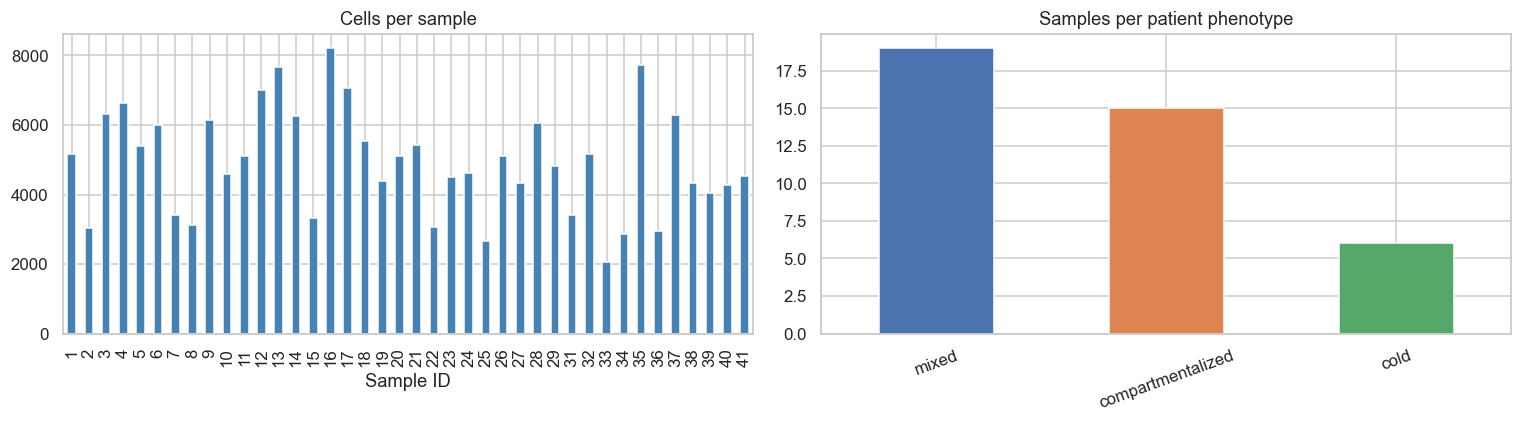

In [9]:
sample_summary = (
    df.groupby("SampleID")
    .agg(
        n_cells=("cellLabelInImage", "count"),
        patient_class=("patient_class", "first"),
        patient_class_label=("patient_class_label", "first"),
        pct_tumor=("tumorYN", lambda s: 100 * (s == 1).mean()),
        pct_immune_group=("Group", lambda s: 100 * (s == 2).mean()),
        median_cell_size=("cellSize", "median"),
        spatial_extent_x=("centroid_x", lambda s: s.max() - s.min()),
        spatial_extent_y=("centroid_y", lambda s: s.max() - s.min()),
    )
    .reset_index()
    .sort_values("SampleID")
)

display(sample_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sample_summary.set_index("SampleID")["n_cells"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Cells per sample")
axes[0].set_xlabel("Sample ID")

sample_level = df[["SampleID", "patient_class_label"]].drop_duplicates()
pc_counts = sample_level["patient_class_label"].value_counts().reindex(PATIENT_CLASS_LABELS.values())
pc_counts.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Samples per patient phenotype")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_sample_overview.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Patient phenotype vs cell composition

group_label,Endothelial,Immune,Keratin-positive tumor,Mesenchymal-like,Tumor,Unidentified
patient_class_label,,,,,,
cold,0.4,3.9,81.1,7.4,5.4,1.9
compartmentalized,1.7,63.7,28.0,4.9,0.7,1.0
mixed,0.6,32.0,62.8,2.6,1.5,0.5


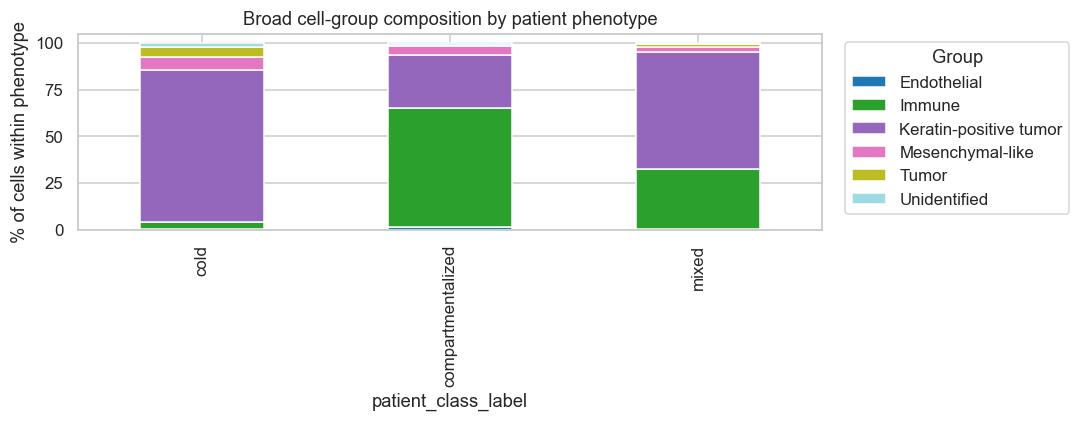

In [10]:
composition = (
    df.groupby(["patient_class_label", "group_label"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
composition["pct_within_class"] = composition.groupby("patient_class_label")["n_cells"].transform(lambda x: 100 * x / x.sum())

pivot = composition.pivot(index="patient_class_label", columns="group_label", values="pct_within_class").fillna(0)
display(pivot.round(1))

fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("% of cells within phenotype")
ax.set_title("Broad cell-group composition by patient phenotype")
ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_composition_by_patient_class.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Cell phenotype distributions

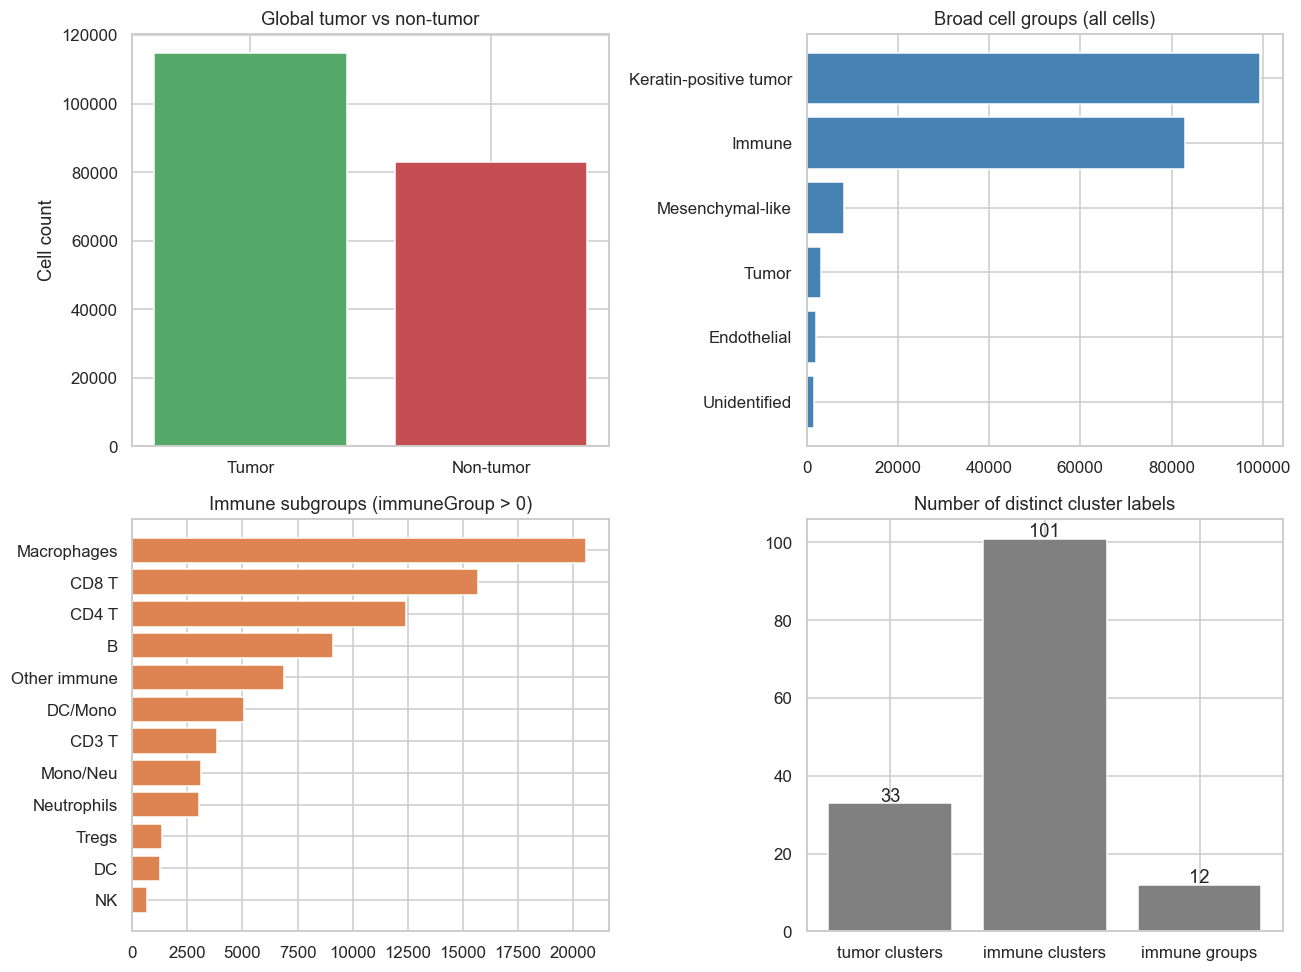

Non-immune cells (immuneGroup=0): 114,635 (58.0%)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Tumor status
tumor_counts = df["tumorYN"].map({0: "Non-tumor", 1: "Tumor"}).value_counts()
axes[0, 0].bar(tumor_counts.index, tumor_counts.values, color=["#55A868", "#C44E52"])
axes[0, 0].set_title("Global tumor vs non-tumor")
axes[0, 0].set_ylabel("Cell count")

# Broad groups
group_counts = df["group_label"].value_counts()
axes[0, 1].barh(group_counts.index, group_counts.values, color="steelblue")
axes[0, 1].set_title("Broad cell groups (all cells)")
axes[0, 1].invert_yaxis()

# Immune subgroups (immuneGroup > 0)
immune_df = df[df["immuneGroup"] > 0]
immune_counts = immune_df["immune_group_label"].value_counts()
axes[1, 0].barh(immune_counts.index, immune_counts.values, color="#DD8452")
axes[1, 0].set_title("Immune subgroups (immuneGroup > 0)")
axes[1, 0].invert_yaxis()

# Cluster cardinality
cluster_card = pd.Series({
    "tumor clusters": df["tumorCluster"].nunique(),
    "immune clusters": df["immuneCluster"].nunique(),
    "immune groups": df.loc[df["immuneGroup"] > 0, "immuneGroup"].nunique(),
})
axes[1, 1].bar(cluster_card.index, cluster_card.values, color="gray")
axes[1, 1].set_title("Number of distinct cluster labels")
for i, v in enumerate(cluster_card.values):
    axes[1, 1].text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_phenotype_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Non-immune cells (immuneGroup=0): {(df['immuneGroup']==0).sum():,} ({100*(df['immuneGroup']==0).mean():.1f}%)")

## 6. Phenotype breakdown by sample and patient class

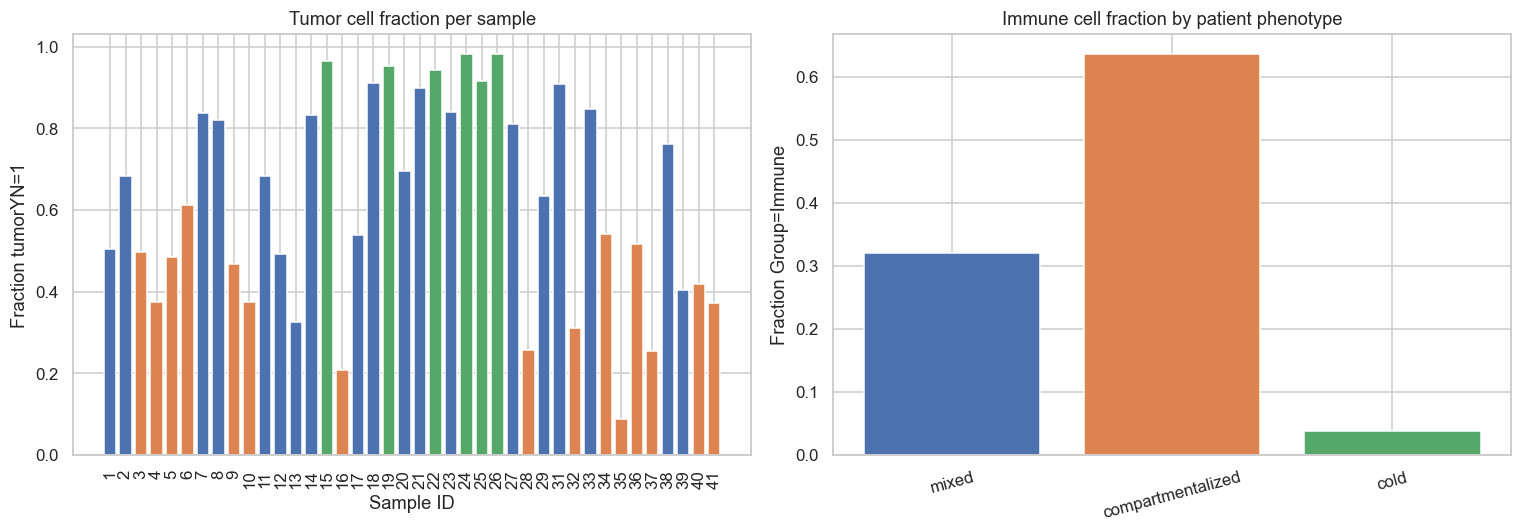

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tumor fraction per sample, colored by patient class
colors = df.groupby("SampleID")["patient_class"].first().map({0: "#4C72B0", 1: "#DD8452", 2: "#55A868"})
tumor_frac = df.groupby("SampleID")["tumorYN"].mean().sort_index()
axes[0].bar(tumor_frac.index.astype(str), tumor_frac.values, color=[colors[s] for s in tumor_frac.index])
axes[0].set_title("Tumor cell fraction per sample")
axes[0].set_xlabel("Sample ID")
axes[0].set_ylabel("Fraction tumorYN=1")
axes[0].tick_params(axis="x", rotation=90)

# Immune fraction by patient class
immune_frac = (
    df.assign(is_immune=df["Group"] == 2)
    .groupby("patient_class_label")["is_immune"]
    .mean()
    .reindex(PATIENT_CLASS_LABELS.values())
)
axes[1].bar(immune_frac.index, immune_frac.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Immune cell fraction by patient phenotype")
axes[1].set_ylabel("Fraction Group=Immune")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_tumor_immune_fractions.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Marker expression — global summary

,count,mean,std,min,5%,25%,50%,75%,95%,max,iqr
B7H3,197678.0,0.000507,1.035277,-0.007057,-0.007057,-0.007057,-0.007057,-0.007057,-0.007057,263.3700,0.000000
CD209,197678.0,0.005697,1.032445,-0.099840,-0.099840,-0.099840,-0.099840,-0.099840,-0.099840,32.4000,0.000000
p53,197678.0,0.021262,1.031830,-0.300460,-0.300460,-0.300460,-0.300460,-0.300460,2.277415,9.5261,0.000000
EGFR,197678.0,0.020508,1.030950,-0.308870,-0.308870,-0.308870,-0.308870,-0.308870,1.812230,26.4080,0.000000
CD56,197678.0,0.003790,1.030746,-0.068127,-0.068127,-0.068127,-0.068127,-0.068127,-0.068127,75.1410,0.000000
CD138,197678.0,0.024315,1.030109,-0.350020,-0.350020,-0.350020,-0.350020,-0.276350,2.092800,16.4710,0.073670
CD16,197678.0,0.023763,1.029893,-0.355310,-0.355310,-0.355310,-0.355310,-0.203710,1.974400,15.5780,0.151600
CD63,197678.0,0.016074,1.027759,-0.283370,-0.283370,-0.283370,-0.283370,-0.283370,1.650215,14.6350,0.000000
Keratin17,197678.0,0.004200,1.026082,-0.273800,-0.273800,-0.273800,-0.273800,-0.273800,1.728630,12.4820,0.000000
Keratin6,197678.0,0.029834,1.024495,-0.527690,-0.527690,-0.527690,-0.449230,0.076250,2.447100,7.1325,0.603940


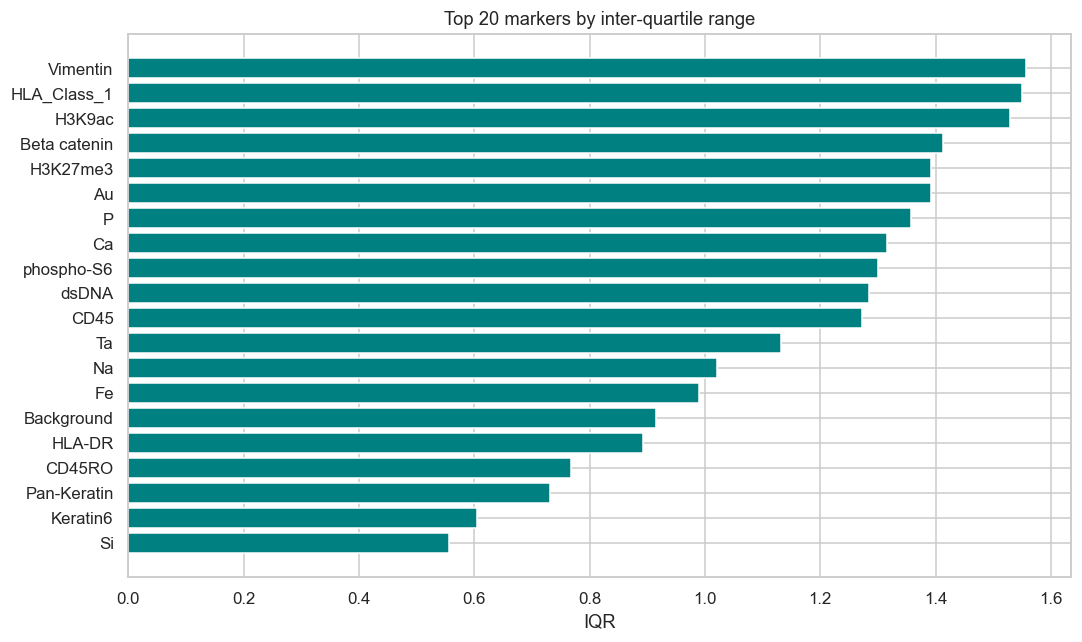

In [13]:
marker_stats = df[existing_markers].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
marker_stats["iqr"] = marker_stats["75%"] - marker_stats["25%"]
marker_stats = marker_stats.sort_values("std", ascending=False)
display(marker_stats.head(15))

# Markers with highest dynamic range (IQR)
fig, ax = plt.subplots(figsize=(10, 6))
top_iqr = marker_stats.sort_values("iqr", ascending=False).head(20)
ax.barh(top_iqr.index[::-1], top_iqr["iqr"][::-1], color="teal")
ax.set_xlabel("IQR")
ax.set_title("Top 20 markers by inter-quartile range")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_marker_iqr.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Marker distributions (key immune / tumor markers)

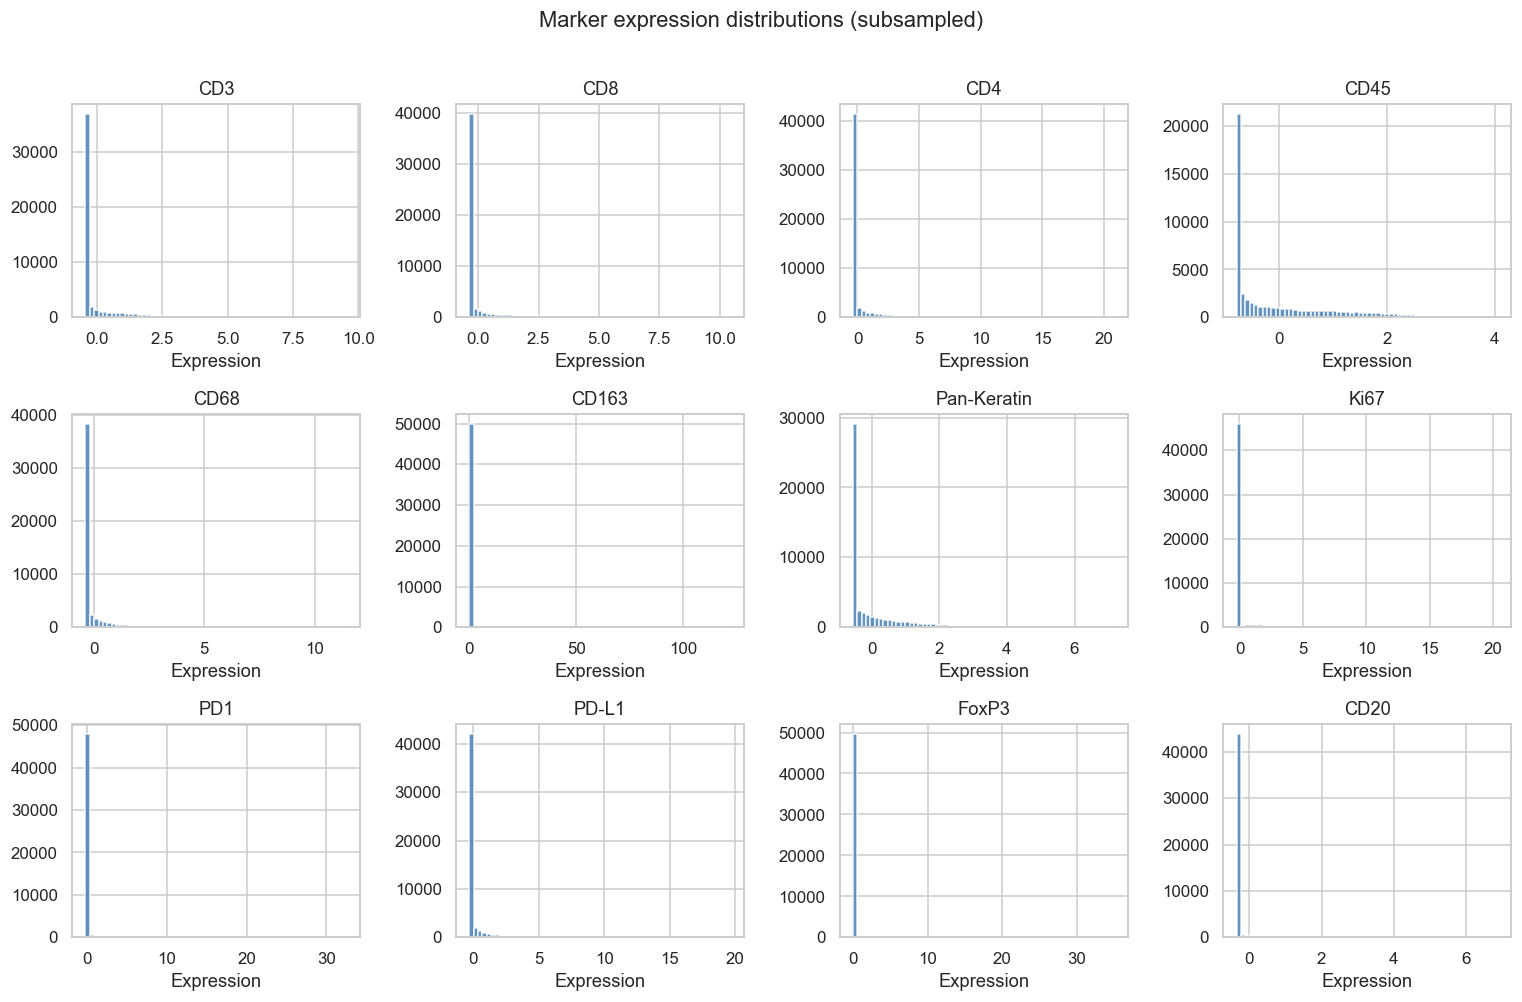

In [14]:
plot_markers = [m for m in KEY_MARKERS if m in df.columns]
n = len(plot_markers)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = axes.flatten()

for ax, marker in zip(axes, plot_markers):
    vals = df[marker]
    # subsample for speed on large histograms
    if len(vals) > 50_000:
        vals = vals.sample(50_000, random_state=0)
    ax.hist(vals, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(marker)
    ax.set_xlabel("Expression")

for ax in axes[len(plot_markers):]:
    ax.axis("off")

plt.suptitle("Marker expression distributions (subsampled)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_key_marker_histograms.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Marker correlation structure

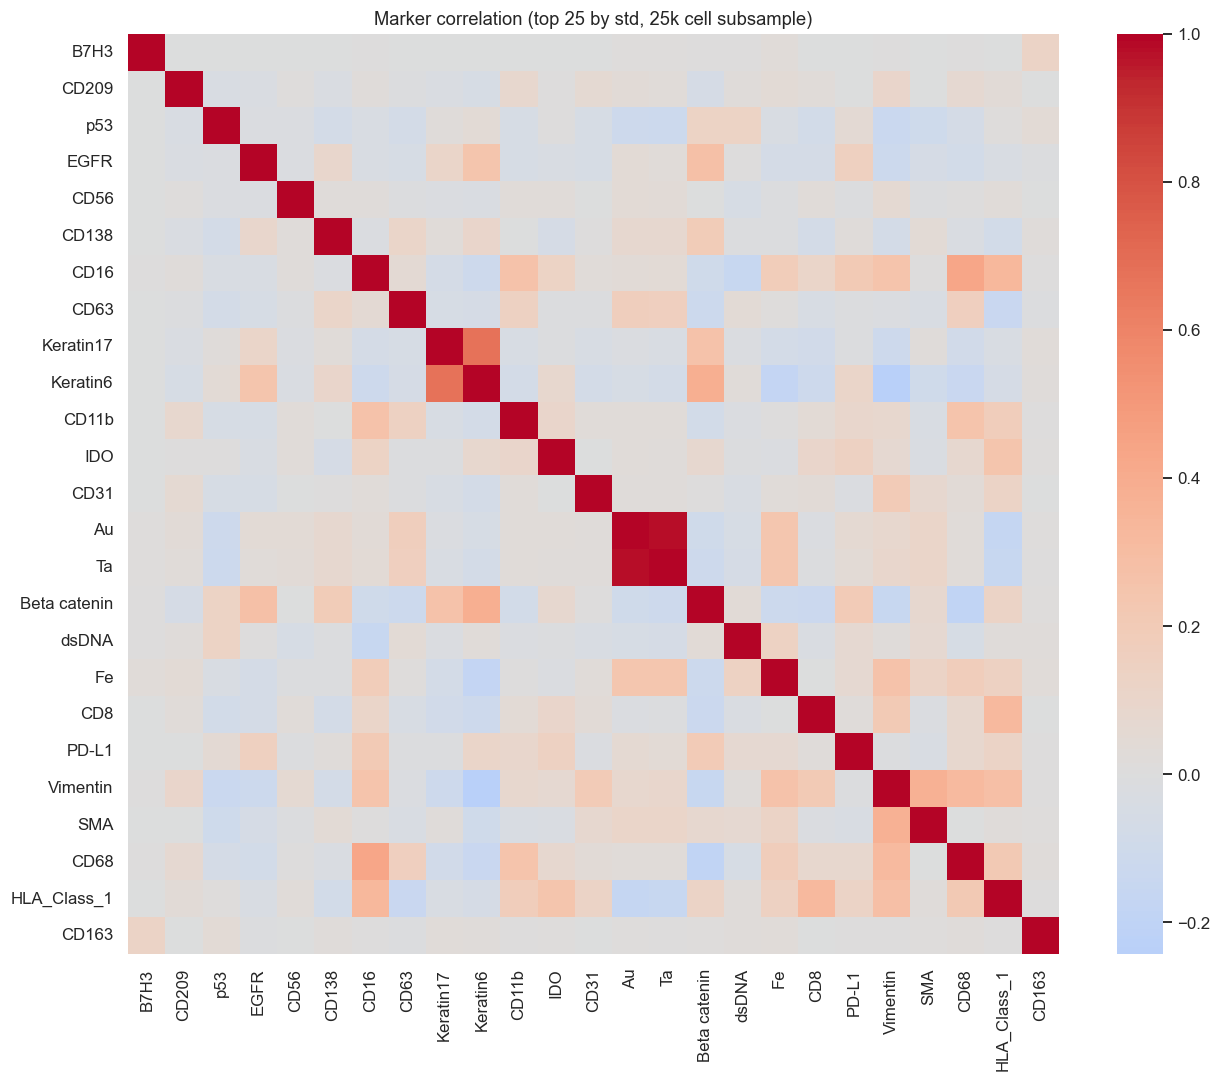

In [15]:
# Use a random subsample for correlation to keep the notebook responsive
corr_sample = df.sample(min(25_000, len(df)), random_state=0)
corr = corr_sample[existing_markers].corr()

# Full heatmap is unreadable; show clustered subset of high-variance markers
top_var_markers = marker_stats.head(25).index.tolist()
corr_sub = corr.loc[top_var_markers, top_var_markers]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_sub, cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Marker correlation (top 25 by std, 25k cell subsample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_marker_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Marker expression by broad cell group

C:\Users\Kelly\AppData\Local\Temp\ipykernel_33588\2773253078.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(3000, len(g)), random_state=0))


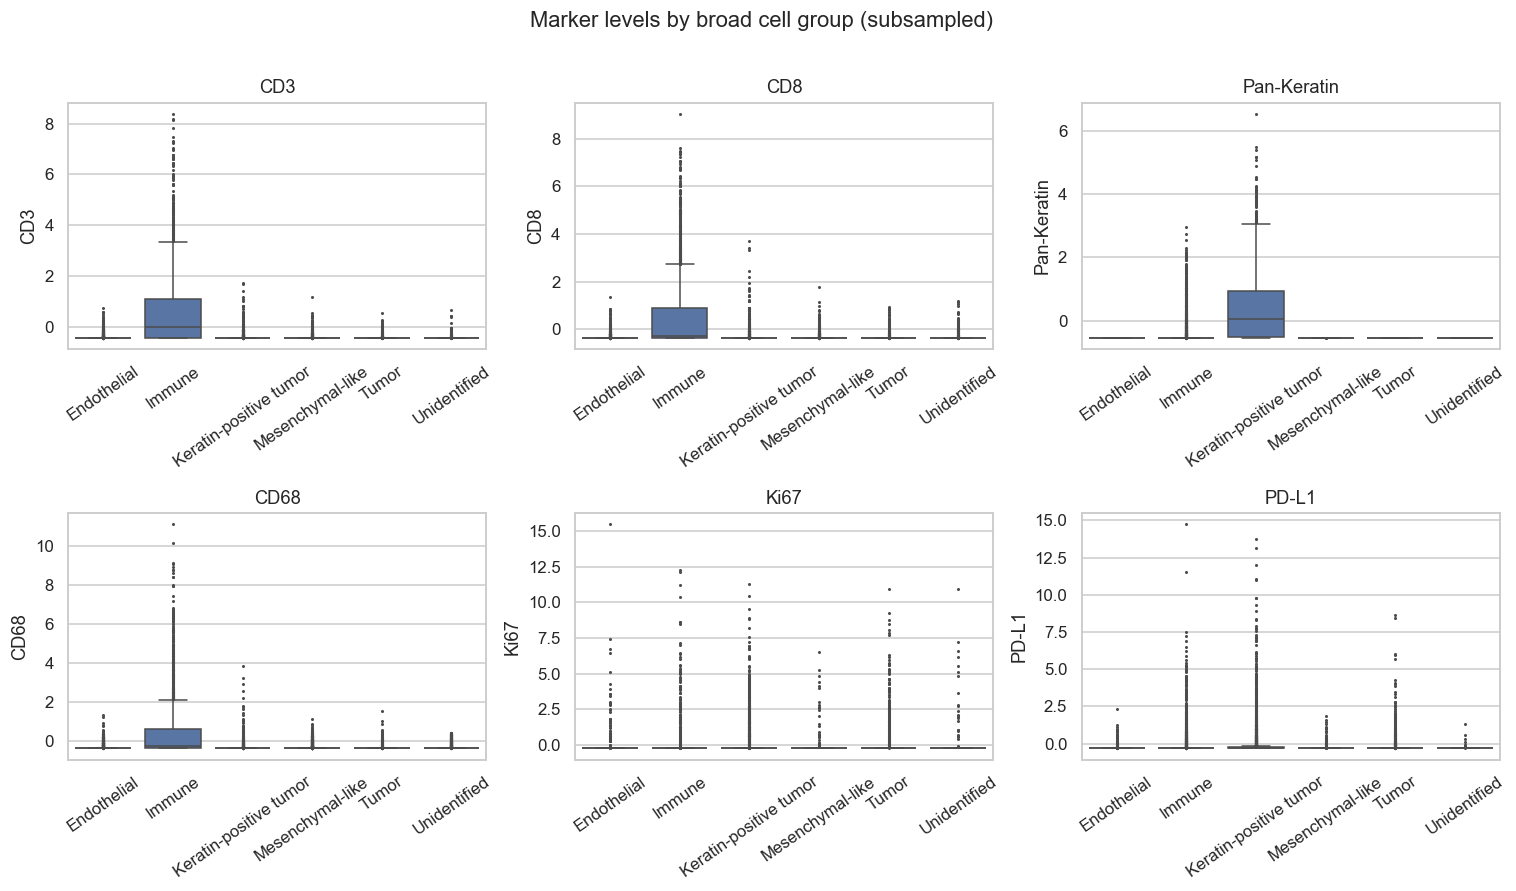

In [16]:
box_markers = [m for m in ["CD3", "CD8", "Pan-Keratin", "CD68", "Ki67", "PD-L1"] if m in df.columns]
plot_df = df[["group_label"] + box_markers].copy()

# subsample per group for plotting
plot_df = (
    plot_df.groupby("group_label", group_keys=False)
    .apply(lambda g: g.sample(min(3000, len(g)), random_state=0))
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, marker in zip(axes.flatten(), box_markers):
    sns.boxplot(data=plot_df, x="group_label", y=marker, ax=ax, fliersize=1)
    ax.set_xlabel("")
    ax.set_title(marker)
    ax.tick_params(axis="x", rotation=35)

plt.suptitle("Marker levels by broad cell group (subsampled)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_markers_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Marker expression by patient phenotype

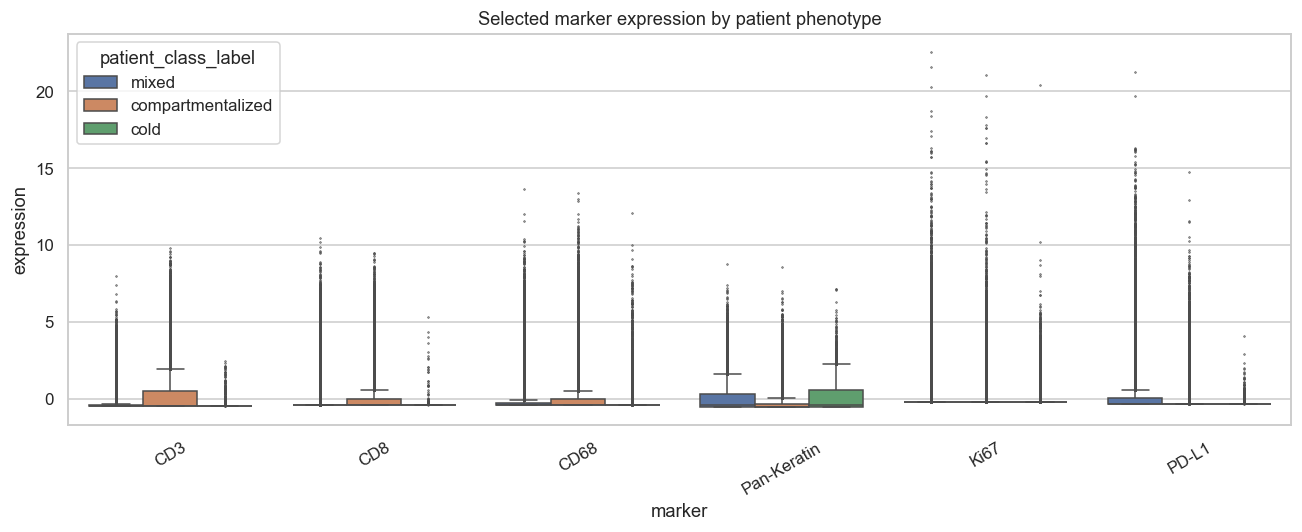

In [17]:
compare_markers = [m for m in ["CD3", "CD8", "CD68", "Pan-Keratin", "Ki67", "PD-L1"] if m in df.columns]
long_df = df[["patient_class_label"] + compare_markers].melt(
    id_vars="patient_class_label", var_name="marker", value_name="expression"
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=long_df,
    x="marker",
    y="expression",
    hue="patient_class_label",
    ax=ax,
    fliersize=0.5,
)
ax.set_title("Selected marker expression by patient phenotype")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_markers_by_patient_class.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Cell size and segmentation QC

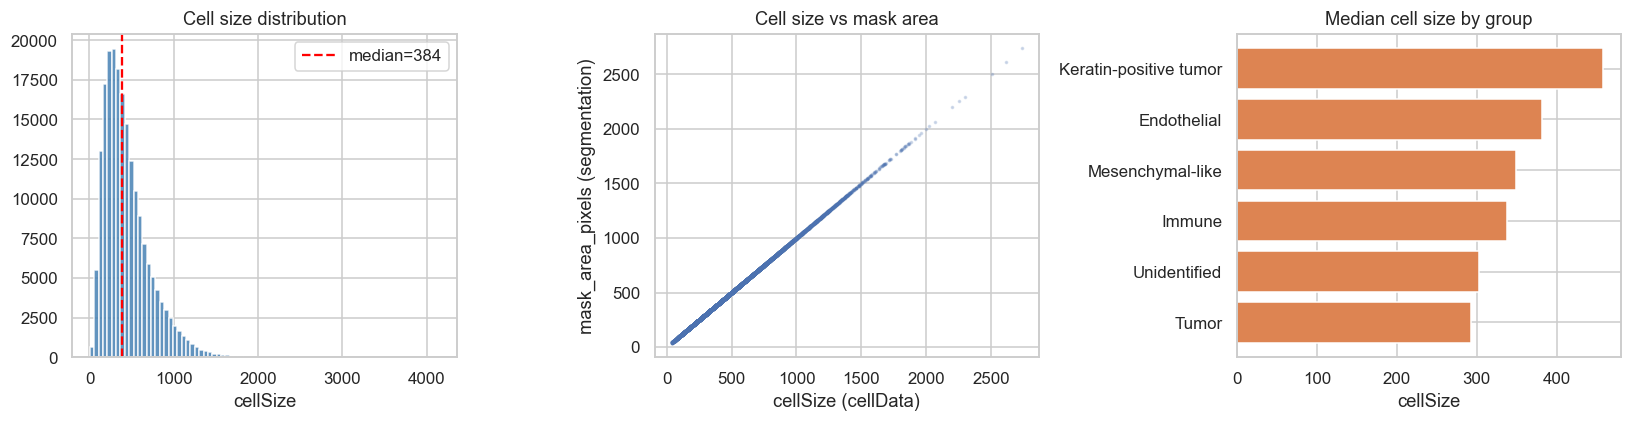

Pearson r(cellSize, mask_area_pixels): 1.0


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["cellSize"], bins=80, color="steelblue", alpha=0.85)
axes[0].set_xlabel("cellSize")
axes[0].set_title("Cell size distribution")
axes[0].axvline(df["cellSize"].median(), color="red", ls="--", label=f"median={df['cellSize'].median():.0f}")
axes[0].legend()

axes[1].scatter(
    df.sample(min(20_000, len(df)), random_state=0)["cellSize"],
    df.sample(min(20_000, len(df)), random_state=0)["mask_area_pixels"],
    s=2, alpha=0.2,
)
axes[1].set_xlabel("cellSize (cellData)")
axes[1].set_ylabel("mask_area_pixels (segmentation)")
axes[1].set_title("Cell size vs mask area")

size_by_group = df.groupby("group_label")["cellSize"].median().sort_values()
axes[2].barh(size_by_group.index, size_by_group.values, color="#DD8452")
axes[2].set_title("Median cell size by group")
axes[2].set_xlabel("cellSize")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_cell_size_qc.png", dpi=200, bbox_inches="tight")
plt.show()

print("Pearson r(cellSize, mask_area_pixels):", df["cellSize"].corr(df["mask_area_pixels"]))

## 13. Spatial layout — density and extent

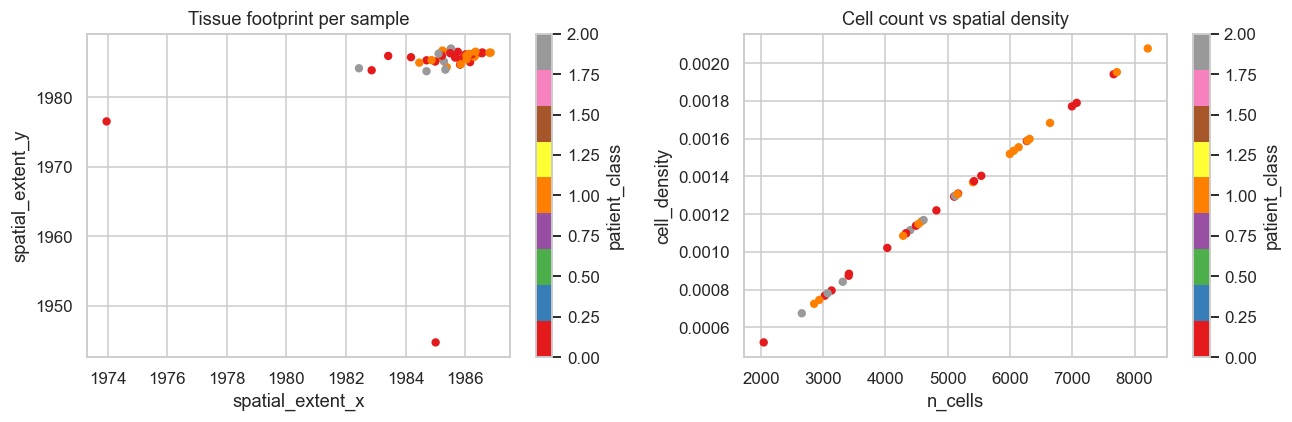

In [19]:
sample_summary["cell_density"] = sample_summary["n_cells"] / (
    (sample_summary["spatial_extent_x"] + 1) * (sample_summary["spatial_extent_y"] + 1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_summary.plot.scatter(x="spatial_extent_x", y="spatial_extent_y", c="patient_class", cmap="Set1", ax=axes[0])
axes[0].set_title("Tissue footprint per sample")
sample_summary.plot.scatter(x="n_cells", y="cell_density", c="patient_class", cmap="Set1", ax=axes[1])
axes[1].set_title("Cell count vs spatial density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_spatial_density.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Spatial maps — one sample per patient phenotype

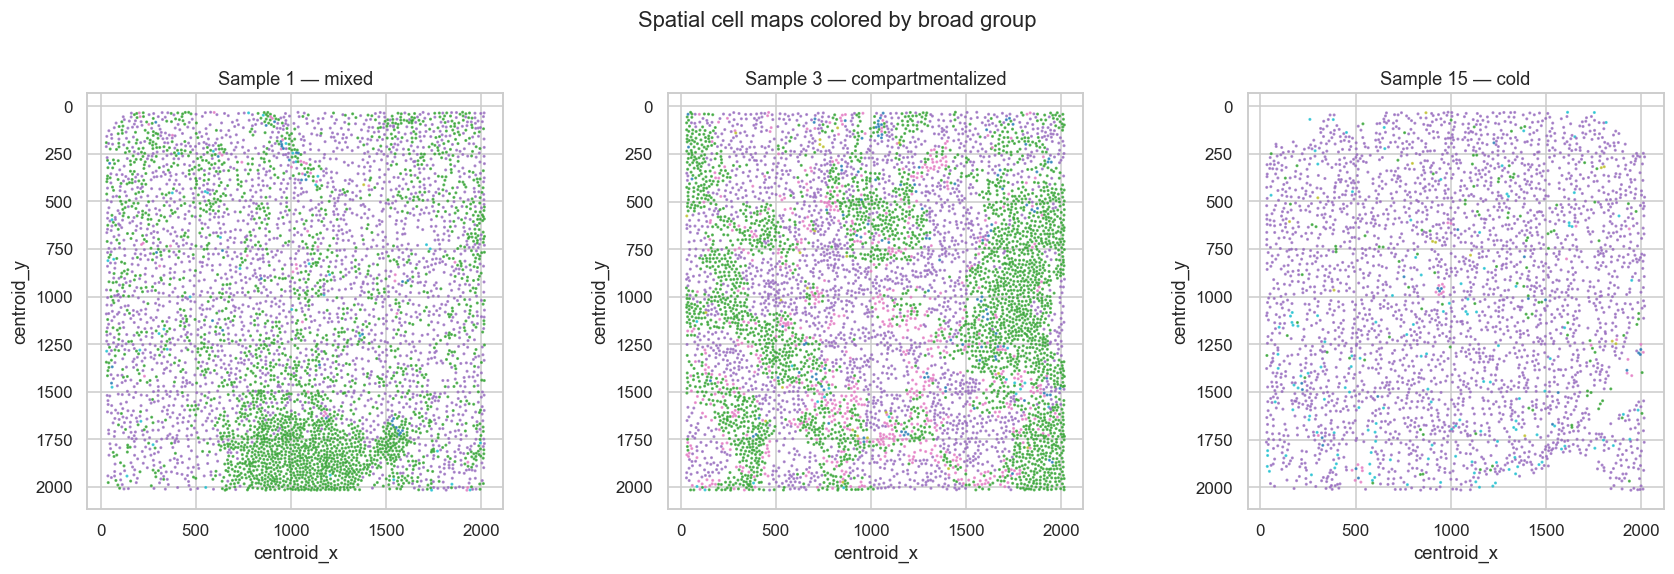

In [25]:
def plot_spatial_sample(sample_id: int, color_col: str, title: str, max_points: int = 40_000):
    sub = df[df["SampleID"] == sample_id]
    if len(sub) > max_points:
        sub = sub.sample(max_points, random_state=0)
    fig, ax = plt.subplots(figsize=(6, 6))
    if color_col == "group_label":
        groups = sub["group_label"].astype("category")
        codes = groups.cat.codes
        sc = ax.scatter(sub["centroid_x"], sub["centroid_y"], c=codes, s=1, cmap="tab10", alpha=0.7)
        ax.legend(handles=sc.legend_elements()[0], labels=list(groups.cat.categories), loc="upper right", fontsize=7)
    else:
        sc = ax.scatter(sub["centroid_x"], sub["centroid_y"], c=sub[color_col], s=1, cmap="viridis", alpha=0.7)
        plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("centroid_x")
    ax.set_ylabel("centroid_y")
    return fig

# Pick first sample in each patient class
examples = (
    df.groupby("patient_class")["SampleID"]
    .min()
    .rename("sample_id")
    .reset_index()
)
examples["label"] = examples["patient_class"].map(PATIENT_CLASS_LABELS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, row in zip(axes, examples.itertuples()):
    sid = row.sample_id
    sub = df[df["SampleID"] == sid]
    if len(sub) > 40_000:
        sub = sub.sample(40_000, random_state=0)
    groups = sub["group_label"].astype("category")
    sc = ax.scatter(sub["centroid_x"], sub["centroid_y"], c=groups.cat.codes, s=1, cmap="tab10", alpha=0.7)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"Sample {sid} — {row.label}")
    ax.set_xlabel("centroid_x")
    ax.set_ylabel("centroid_y")

plt.suptitle("Spatial cell maps colored by broad group", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_spatial_maps_by_phenotype.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Spatial immune infiltration maps

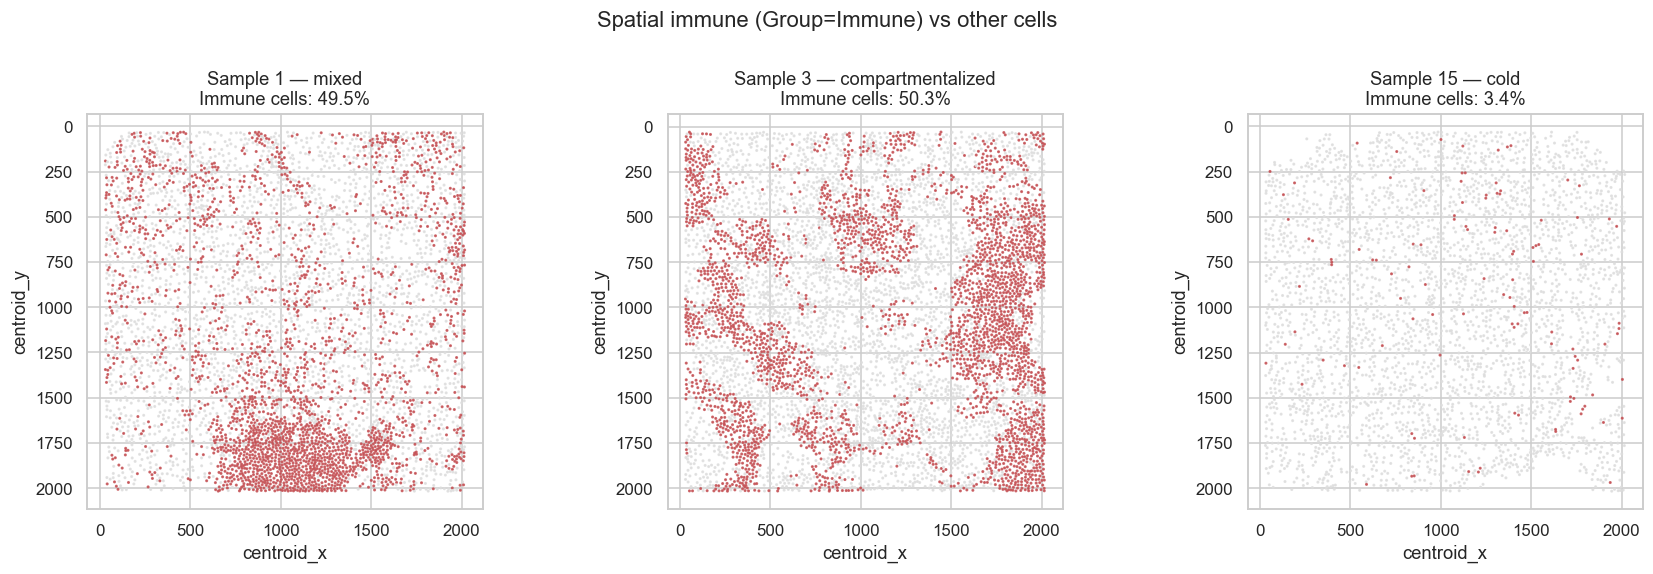

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, row in zip(axes, examples.itertuples()):
    sid = row.sample_id
    sub = df[df["SampleID"] == sid]
    if len(sub) > 40_000:
        sub = sub.sample(40_000, random_state=0)
    is_immune = (sub["Group"] == 2).astype(int)
    ax.scatter(
        sub["centroid_x"], sub["centroid_y"],
        c=np.where(is_immune, "#C44E52", "#DDDDDD"),
        s=1, alpha=0.8,
    )
    ax.invert_yaxis()
    ax.set_aspect("equal")
    pct = 100 * is_immune.mean()
    ax.set_title(f"Sample {sid} — {row.label}\nImmune cells: {pct:.1f}%")
    ax.set_xlabel("centroid_x")
    ax.set_ylabel("centroid_y")

plt.suptitle("Spatial immune (Group=Immune) vs other cells", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_spatial_immune_maps.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Cross-tabulations

In [27]:
ct_tumor_group = pd.crosstab(df["group_label"], df["tumorYN"], normalize="index").round(3)
display(ct_tumor_group)

ct_patient_immune = pd.crosstab(
    df["patient_class_label"],
    df["immune_group_label"],
    normalize="index",
).round(4)
# show only immune subgroups with meaningful mass
immune_cols = ct_patient_immune.columns[ct_patient_immune.sum() > 0.01]
display(ct_patient_immune[immune_cols].T)

tumorYN,0,1
group_label,,
Endothelial,0.0,1.0
Immune,1.0,0.0
Keratin-positive tumor,0.0,1.0
Mesenchymal-like,0.0,1.0
Tumor,0.0,1.0
Unidentified,0.0,1.0


patient_class_label,cold,compartmentalized,mixed
immune_group_label,,,
B,0.0001,0.0850,0.0224
CD3 T,0.0006,0.0293,0.0153
CD4 T,0.0016,0.1179,0.0285
CD8 T,0.0007,0.1091,0.0723
DC,0.0001,0.0140,0.0008
DC/Mono,0.0024,0.0443,0.0144
Macrophages,0.0250,0.1285,0.1024
Mono/Neu,0.0025,0.0205,0.0147
Neutrophils,0.0029,0.0140,0.0196


## 17. Key findings summary

In [28]:
summary_lines = [
    f"Total cells: {len(df):,} across {df['SampleID'].nunique()} samples",
    f"Patient phenotypes: " + ", ".join(
        f"{PATIENT_CLASS_LABELS[k]}={v}" for k, v in df.groupby('patient_class')['SampleID'].nunique().items()
    ),
    f"Tumor vs non-tumor: {100*df['tumorYN'].mean():.1f}% tumorYN=1",
    f"Immune cells (Group=2): {100*(df['Group']==2).mean():.1f}%",
    f"Median cell size: {df['cellSize'].median():.0f} (IQR {df['cellSize'].quantile(0.25):.0f}–{df['cellSize'].quantile(0.75):.0f})",
    f"All critical fields complete: patient_class, centroid_x, centroid_y have 0 missing",
    f"Excluded samples 42–44 per pipeline (no patient_class labels in source data)",
]

print("\n".join(f"• {line}" for line in summary_lines))
print(f"\nFigures saved under: {FIGURES_DIR}")

• Total cells: 197,678 across 40 samples
• Patient phenotypes: mixed=19, compartmentalized=15, cold=6
• Tumor vs non-tumor: 58.0% tumorYN=1
• Immune cells (Group=2): 42.0%
• Median cell size: 384 (IQR 248–580)
• All critical fields complete: patient_class, centroid_x, centroid_y have 0 missing
• Excluded samples 42–44 per pipeline (no patient_class labels in source data)

Figures saved under: c:\Users\Kelly\Documents\spatial-ihc-feature-lab\reports\figures\eda_notebook
